# LassoARE Demo (using scRNA-seq DFU dataset)

This notebook demonstrates the LassoARE workflow using a DFU dataset

This dataset can be downloaded at [http://secure.bioxai.cn/Lasso-ARE/adata_fib.h5ad](http://secure.bioxai.cn/Lasso-ARE/adata_fib.h5ad).

In [1]:
# # download dataset
# import urllib.request
#
# url = "http://secure.bioxai.cn/Lasso-ARE/adata_fib.h5ad"
# output_name = "adata_fib.h5ad"
#
# urllib.request.urlretrieve(url, output_name)
# print("download completed")

In [2]:
import os
import sys
sys.path.append('.')
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

file_path='./adata_fib.h5ad'
output_dir = "./new_adata"

### Step 1: Simulate User Selection
We will read the selected cell indices from the file `selection.txt` to simulate a user selecting cells in a visualization tool.

In [3]:
full_select_path="./selection.txt"
select_file=open(full_select_path, 'r')
selected_list=[]
for line in select_file:
    selected_list.append(eval(line.strip()))
selected_list2=selected_list[0]

### Step 2: Refine selection with do_lasso
We run Label Propagation using the file-based `do_lasso_file` function.

/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


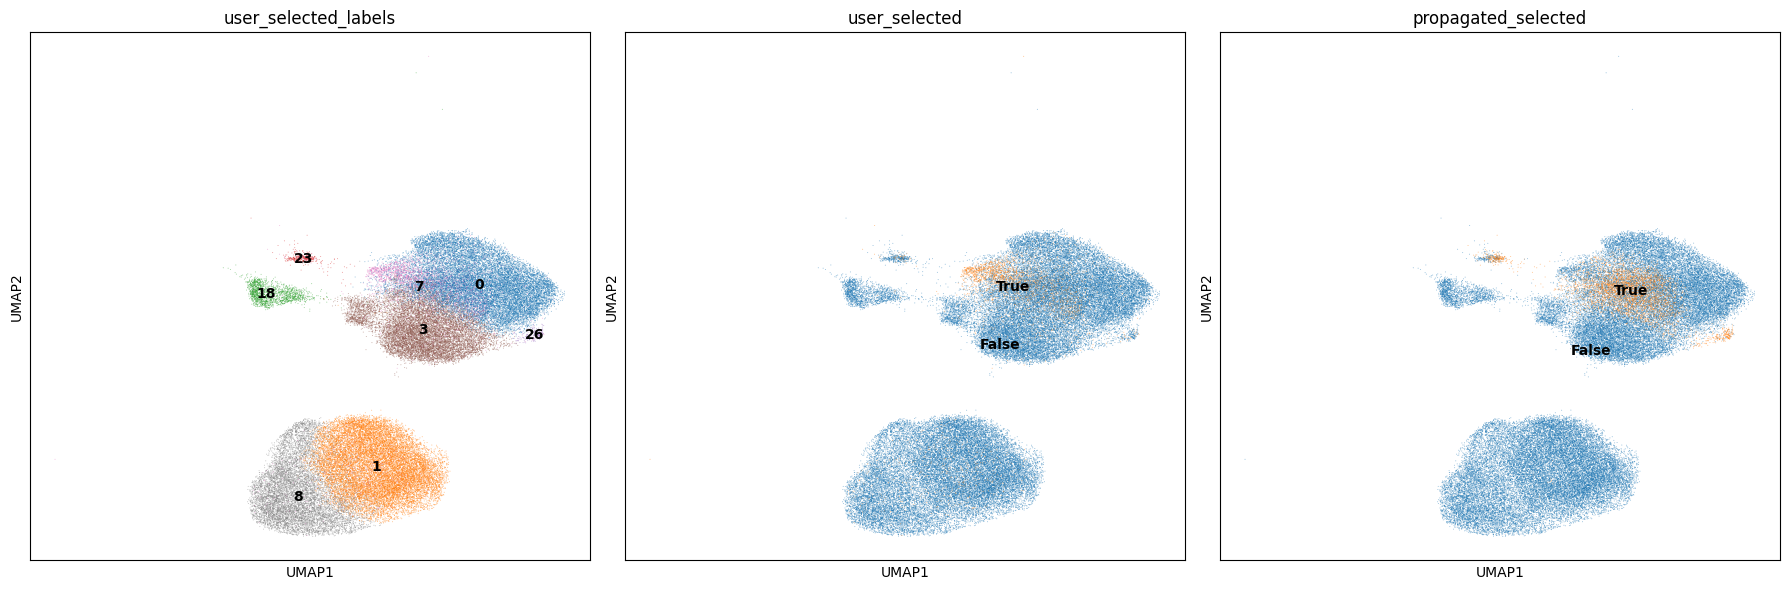

3447
7393


In [4]:
from do_lasso import do_lasso_file
lasso_list2=do_lasso_file(file_path, selected_list2,obs_col='leiden-1', vis=True, vis_key='leiden-1', do_correct=True)
print(len(selected_list2))
print(len(lasso_list2))

In [5]:
# Wrap flat list into nested list format (each list represents a user-selected group)
selected_groups = [selected_list2]  # Single group: all selected points
lasso_groups = [lasso_list2]  # Single group: all lasso selected points

In [6]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
adata = sc.read_h5ad(file_path)
print(adata)
selected_group=np.array(['False']*adata.n_obs)
lasso_group=np.array(['False']*adata.n_obs)
for i in selected_groups[0]:
    selected_group[i]='True'
for i in lasso_groups[0]:
    lasso_group[i]='True'
adata.obs['selected_group'] = pd.Categorical(selected_group)
adata.obs['lasso_group'] = pd.Categorical(lasso_group)

AnnData object with n_obs × n_vars = 60727 × 24238
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden-1', 'condition_l0', 'condition_l1', 'condition_l2', 'condition_raw', 'manual_selected'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'condition_l0_colors', 'condition_l1_colors', 'condition_l2_colors', 'hvg', 'leiden-1', 'leiden-1_colors', 'log1p', 'manual_selected_colors', 'neighbors', 'pca', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'Raw'
    obsp: 'connectivities', 'distances'


/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


### Step 3: Recluster and visualize
We recluster the dataset using the adaptively refined selection, and visualize the comparisons.

Number of user groups: 1
Total selected points: 7393
Using device: cuda


/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Data shape: (60727, 24238)
Applying PCA: reducing from 24238 to 500 dimensions...
Number of user-selected groups: 1
Pretraining autoencoder...
Pretraining autoencoder...
Pretrain epoch [1/20], ZINB loss: 0.8860
Pretrain epoch [20/20], ZINB loss: 0.2935
Training adversarial clustering model...
Pretraining discriminators...
Pretrain Disc Epoch 10/20: Loss = 0.3724, Acc = 0.9594
Pretrain Disc Epoch 20/20: Loss = 0.3643, Acc = 0.9669
--- Epoch 1/5 ---
  Disc Loss: 0.3639, Disc Acc: 0.9673
  Gen Loss: 0.6223
  Loss Components (Avg Weighted): Recon=0.2965, Cluster=0.3095, AdvAttn=0.0162
                              Inner=0.0000, Outer=0.0000, Consist=0.0000
  Group 1 distribution: {np.int64(0): np.int64(402), np.int64(1): np.int64(5), np.int64(2): np.int64(51), np.int64(4): np.int64(614), np.int64(5): np.int64(315), np.int64(6): np.int64(148), np.int64(7): np.int64(205), np.int64(9): np.int64(1), np.int64(10): np.int64(1615), np.int64(12): np.int64(4), np.int64(13): np.int64(425), np.int64(

/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/c/Code/lasso_are/project/submit/LassoARE/recluster_scRNA.py:251: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(leiden_adata, key_added='leiden_LassoARE', resolution=leiden_r)


Reclustering completed!
Result saved to: ./new_adata/reclustered_adata_test_42.h5ad
Plotting visualization comparisons...


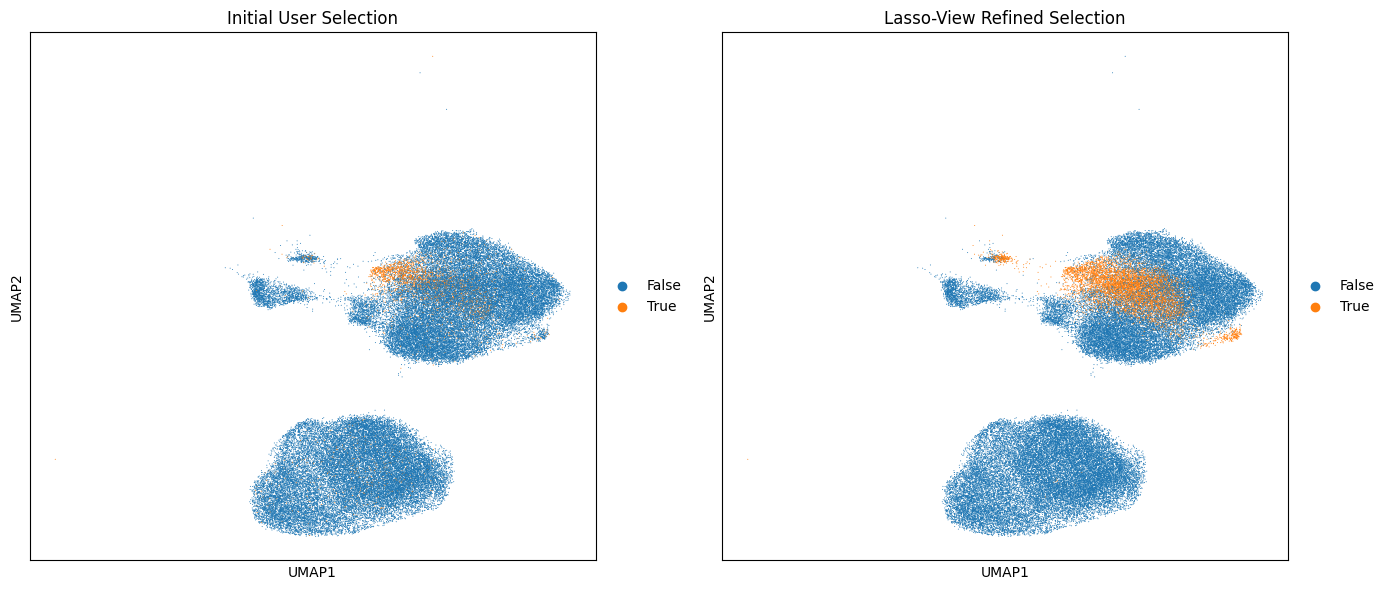

/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 60727 × 24238
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden-1', 'condition_l0', 'condition_l1', 'condition_l2', 'condition_raw', 'manual_selected', 'selected_group', 'lasso_group', 'LassoARE_selected', 'LassoARE_clusters', 'leiden_LassoARE'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'condition_l0_colors', 'condition_l1_colors', 'condition_l2_colors', 'hvg', 'leiden-1', 'leiden-1_colors', 'log1p', 'manual_selected_colors', 'neighbors', 'pca', 'scrublet', 'umap', 'LassoARE_pca', 'selected_group_colors', 'lasso_group_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'LassoARE_latent', 'X_umap_LassoARE'
    varm: 'PCs'
    layers: 'R

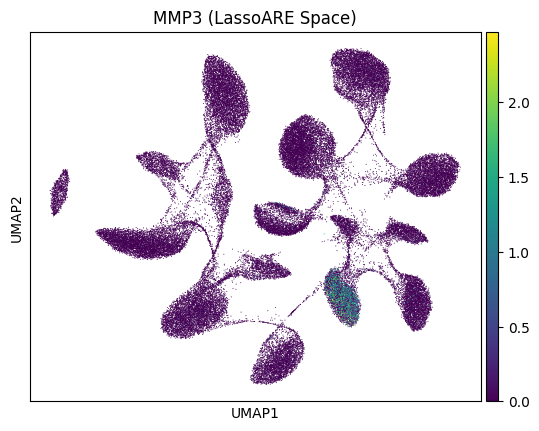

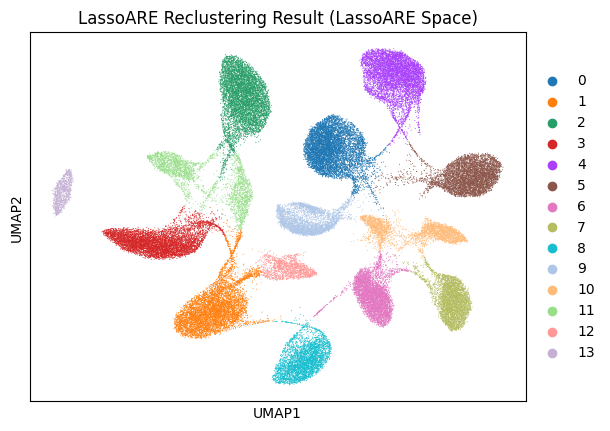

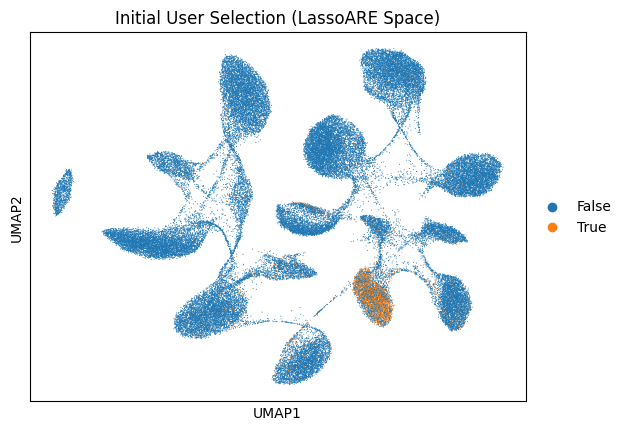

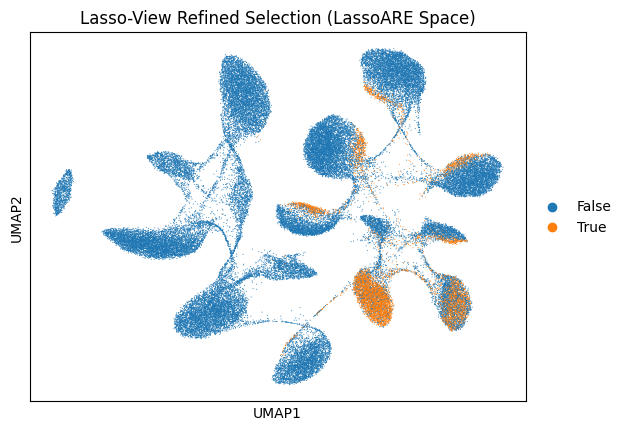

=== seed 42 completed ===

Number of user groups: 1
Total selected points: 3447
Using device: cuda


/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Data shape: (60727, 24238)
Applying PCA: reducing from 24238 to 500 dimensions...
Number of user-selected groups: 1
Pretraining autoencoder...
Pretraining autoencoder...
Pretrain epoch [1/20], ZINB loss: 0.8860
Pretrain epoch [20/20], ZINB loss: 0.2935
Training adversarial clustering model...
Pretraining discriminators...
Pretrain Disc Epoch 10/20: Loss = 0.3622, Acc = 0.9712
Pretrain Disc Epoch 20/20: Loss = 0.3601, Acc = 0.9723
--- Epoch 1/5 ---
  Disc Loss: 0.3598, Disc Acc: 0.9731
  Gen Loss: 0.6257
  Loss Components (Avg Weighted): Recon=0.2966, Cluster=0.3045, AdvAttn=0.0246
                              Inner=0.0000, Outer=0.0000, Consist=0.0000
  Group 1 distribution: {np.int64(0): np.int64(21), np.int64(1): np.int64(1), np.int64(2): np.int64(41), np.int64(3): np.int64(38), np.int64(4): np.int64(27), np.int64(6): np.int64(39), np.int64(7): np.int64(47), np.int64(8): np.int64(1), np.int64(9): np.int64(271), np.int64(10): np.int64(171), np.int64(11): np.int64(36), np.int64(12): n

/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Reclustering completed!
Result saved to: ./new_adata/reclustered_adata_test_woLasso_42.h5ad
Plotting visualization comparisons...


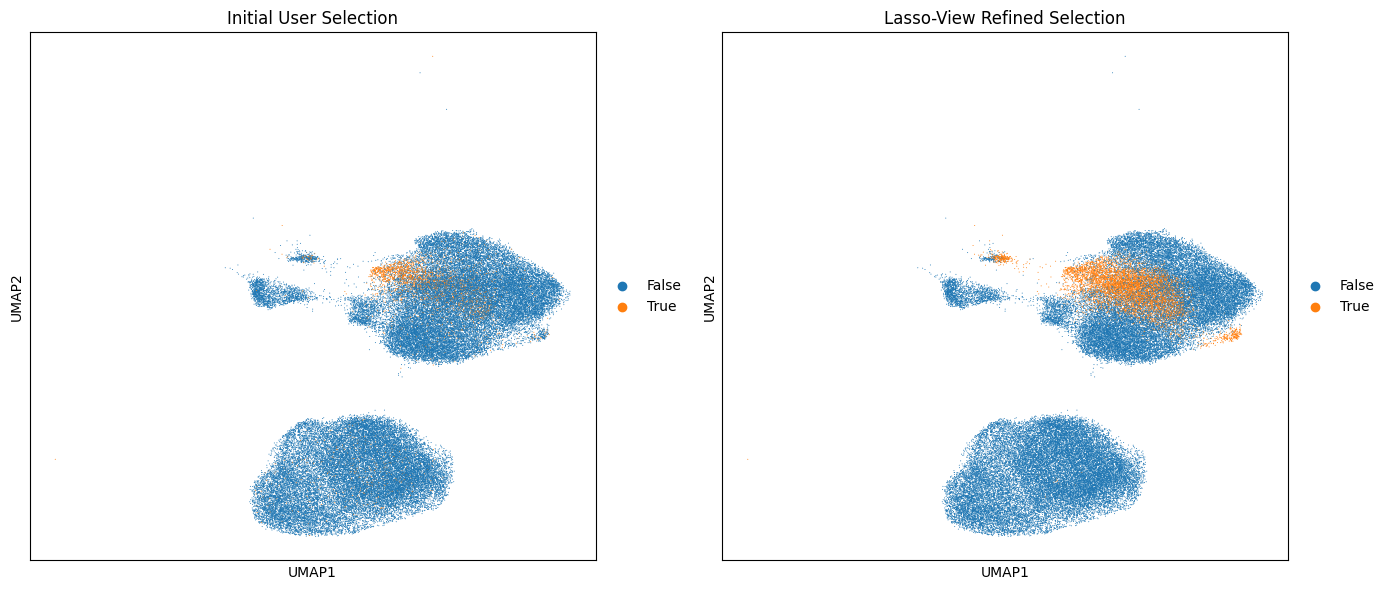

/home/kyotsukitankou/anaconda3/envs/lasso_are/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 60727 × 24238
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden-1', 'condition_l0', 'condition_l1', 'condition_l2', 'condition_raw', 'manual_selected', 'selected_group', 'lasso_group', 'LassoARE_selected', 'LassoARE_clusters', 'leiden_LassoARE'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'condition_l0_colors', 'condition_l1_colors', 'condition_l2_colors', 'hvg', 'leiden-1', 'leiden-1_colors', 'log1p', 'manual_selected_colors', 'neighbors', 'pca', 'scrublet', 'umap', 'LassoARE_pca', 'selected_group_colors', 'lasso_group_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'LassoARE_latent', 'X_umap_LassoARE'
    varm: 'PCs'
    layers: 'R

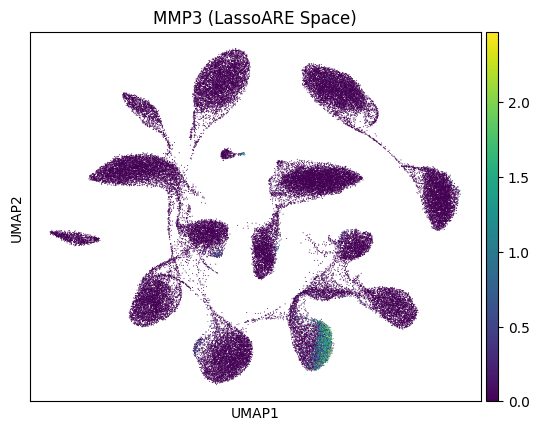

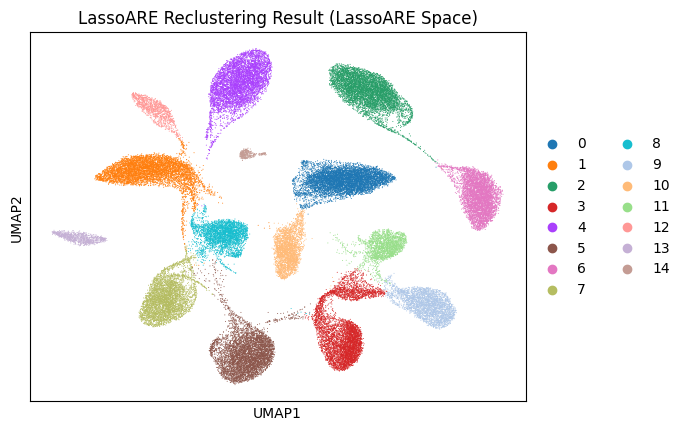

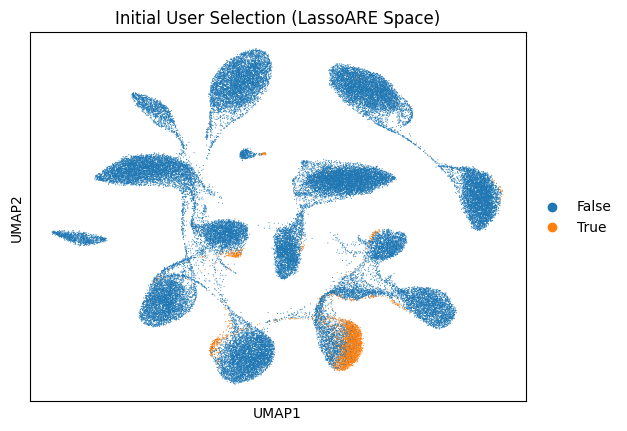

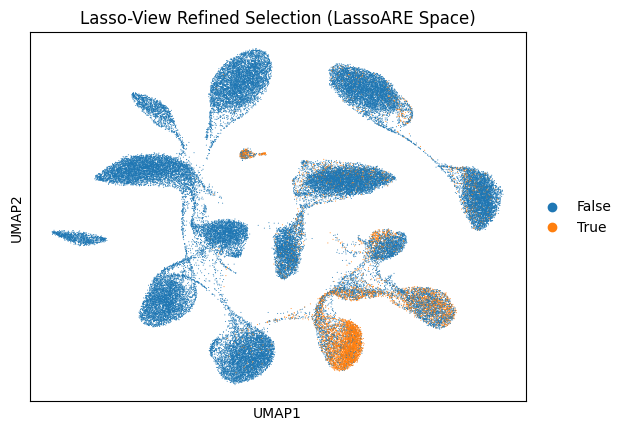

=== seed 42 completed ===



In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
from LassoARE.recluster_scRNA import recluster_with_lasso_are
import torch
import random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def flatten_groups(groups):
    unique_indices = set()
    for group in groups:
        unique_indices.update(group)
    return sorted(unique_indices)
    
def conduct_recluster(input_adata, lasso=True, seed=42):
    user_selected_groups = [lasso_list2] if lasso else [selected_list2]
    flat_selected = flatten_groups(user_selected_groups)
    
    print(f"Number of user groups: {len(user_selected_groups)}")
    print(f"Total selected points: {len(flat_selected)}")
    
    seed_everything(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    adata = input_adata.copy() # sc.read_h5ad(file_path)
    print(f"Data shape: {adata.shape}")
    
    enc_layers = [256, 64]
    dec_layers = [64, 256]
    disc_layers = [256, 64]
    
    reclustered_adata = recluster_with_lasso_are(
        adata=adata,
        user_selected_lists=user_selected_groups,
        n_clusters=16,
        enc_pretrain_epoch=20,
        disc_pretrain_epoch=20,
        gan_epoch=5,
        enc_layers=enc_layers,
        dec_layers=dec_layers,
        disc_layers=disc_layers,
        batch_size=256,
        device=device,
        lambda_attention=0.1,
        lambda_feature=0.0,
        lambda_consistency=0.0,
        lambda_cluster=1.0,
        lambda_recon=1.0,
        leiden_r=0.1,
        z_dim=32,
        is_pca=True,
        pca_dimension=500,
        do_pp=True, # Ensure generation of downstream UMAP projection X_umap_LassoARE
        do_harmony=False,
    )
    
    recluster_suffix = "" if lasso else "_woLasso"
    seed_str = "_" + str(seed)
    
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"reclustered_adata_test{recluster_suffix}{seed_str}.h5ad")
    reclustered_adata.write_h5ad(output_path)
    print(f"Result saved to: {output_path}")
    
    # === Visualization: directly plot using sc.pl.umap ===
    print("Plotting visualization comparisons...")
    
    # 1. Initial selection vs Lasso refined selection on original UMAP
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sc.pl.umap(adata, color='selected_group', ax=axes[0], show=False, title='Initial User Selection')
    sc.pl.umap(adata, color='lasso_group', ax=axes[1], show=False, title='Lasso-View Refined Selection')
    plt.tight_layout()
    plt.show()

    # 2. Plot LassoARE reclustering result (on the adaptively learned new UMAP in latent space)
    adata_copy = reclustered_adata.copy()
    print(adata_copy)
    # fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    adata_copy.obsm['X_umap'] = adata_copy.obsm['X_umap_LassoARE']
    sc.pl.umap(adata_copy, color=['MMP3'], title='MMP3 (LassoARE Space)')
    sc.pl.umap(adata_copy, color=['leiden_LassoARE'], title='LassoARE Reclustering Result (LassoARE Space)')
    sc.pl.umap(adata_copy, color=['selected_group'], title='Initial User Selection (LassoARE Space)')
    sc.pl.umap(adata_copy, color=['lasso_group'], title='Lasso-View Refined Selection (LassoARE Space)')
    # plt.tight_layout()
    # plt.show()

    del reclustered_adata
    del adata
    if device.type == "cuda":
        torch.cuda.empty_cache()
    
    print(f"=== seed {seed} completed ===\n")

if __name__ == "__main__":
    # adata=sc.read_h5ad(file_path)
    conduct_recluster(adata, lasso=True, seed=42)
    conduct_recluster(adata, lasso=False, seed=42)